In [ ]:
'''Turn on MAC mutation again. During two sexual processes, MAC Mutation Rate = 45, which is twice of MIC mutations (per locus 
per generation). MAC mutations are scaled along the asexual generations during two sexual processes.'''

In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


In [3]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180625_Equilibrium of facultative sex_Test. Efficiency of facultative selection\Data\9. Turn on MAC mutation again_Soma MTU =45 During 2 Sexs\RM")

In [4]:
file_gmu1 = ['New_SMU45_GMU1_Fit_P45_RM_E1.csv','New_SMU45_GMU1_Fit_P45_RM_E2.csv','New_SMU45_GMU1_Fit_P45_RM_E5.csv', \
          'New_SMU45_GMU1_Fit_P45_RM_E10.csv', 'New_SMU45_GMU1_Fit_P45_RM_E20.csv', 'New_SMU45_GMU1_Fit_P45_RM_E50.csv',\
             'New_SMU45_GMU1_Fit_P45_RM_E100.csv', 'New_SMU45_GMU1_Fit_P45_RM_E200.csv', 'New_SMU45_GMU1_Fit_P45_RM_E500.csv']

In [5]:
gmu1_fit_mean = []
gmu1_fit_std = []


for i in file_gmu1:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
    
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    

    gmu1_fit_mean.append(fit_mean)
    gmu1_fit_std.append(fit_std)

In [6]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [7]:
def get_fit(gen_file, fit_file, std_file):
    with open(gen_file, 'rb') as f:
        sex_gen = pickle.load(f)
        
    sex_fit_mean = []
    sex_fit_std = []
    for i in sex_gen:
        sex_fit_mean.append(fit_file[i])
        sex_fit_std.append(std_file[i])
        
    return sex_fit_mean, sex_fit_std, sex_gen

In [8]:
total_gen_file = ['New_SMU45_P45_RM_SEX_GEN_E1', 'New_SMU45_P45_RM_SEX_GEN_E2', 'New_SMU45_P45_RM_SEX_GEN_E5', 'New_SMU45_P45_RM_SEX_GEN_E10', \
                 'New_SMU45_P45_RM_SEX_GEN_E20', 'New_SMU45_P45_RM_SEX_GEN_E50','New_SMU45_P45_RM_SEX_GEN_E100','New_SMU45_P45_RM_SEX_GEN_E200', \
                 'New_SMU45_P45_RM_SEX_GEN_E500']

In [9]:
total_fit_file = gmu1_fit_mean
total_std_file = gmu1_fit_std

In [10]:
len(total_std_file)

9

In [11]:
total_sex_fit_mean = []
total_sex_fit_std = []
total_sex_gen = []

for i in range(9):
    e = get_fit(total_gen_file[i], total_fit_file[i], total_std_file[i])
    total_sex_fit_mean.append(e[0])
    total_sex_fit_std.append(e[1])
    total_sex_gen.append(e[2])

In [12]:
len(total_sex_gen[3])

2001

In [13]:
len(total_sex_fit_mean[3])

2001

# Equilibrium fitness comparison_1

Here we used the population mean fitness at the last generation as the equilibrium fitness for comparison, and also the STD is the STD of population mean fitnss in the last generation.

In [14]:
rmu_mean = []
rmu_std = []

for i in range(len(total_sex_fit_mean)):
    rmu_mean.append(total_sex_fit_mean[i][-1])
    rmu_std.append(total_sex_fit_std[i][-1])

In [15]:
rmu_mean

[0.36112972003888572,
 0.59166270152699452,
 0.79627312809453954,
 0.88102993741693969,
 0.9219836837280494,
 0.94394525058350642,
 0.9467671842302765,
 0.94699177108529164,
 0.94729732683150347]

In [16]:
rmu_std

[0.012867043950464048,
 0.015184303886344001,
 0.013673394677084097,
 0.013227861187747268,
 0.0081602757092233968,
 0.0060754597413400615,
 0.0069449345182319346,
 0.0081984735171333062,
 0.010259592237913721]

In [17]:
rm_expect = np.exp(-1)
rm_expect

0.36787944117144233

In [18]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 18})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

# Comparison with RM P45A_S =0.1_Turn off MAC mutations

In [19]:
s1_mean = [0.36411616264196278,
 0.59516912899421293,
 0.80025187988609947,
 0.87833061652167177,
 0.92216821618517741,
 0.9438233513248856,
 0.94845313356706584,
 0.94591030315302171,
 0.94791286013791398]

In [20]:
s1_std = [0.015257661638551015,
 0.015805704602902523,
 0.014316240519077362,
 0.012430062516646776,
 0.0079018675878586193,
 0.0063823024799571585,
 0.0049315140827972071,
 0.0080718885422322532,
 0.0098357329673968014]

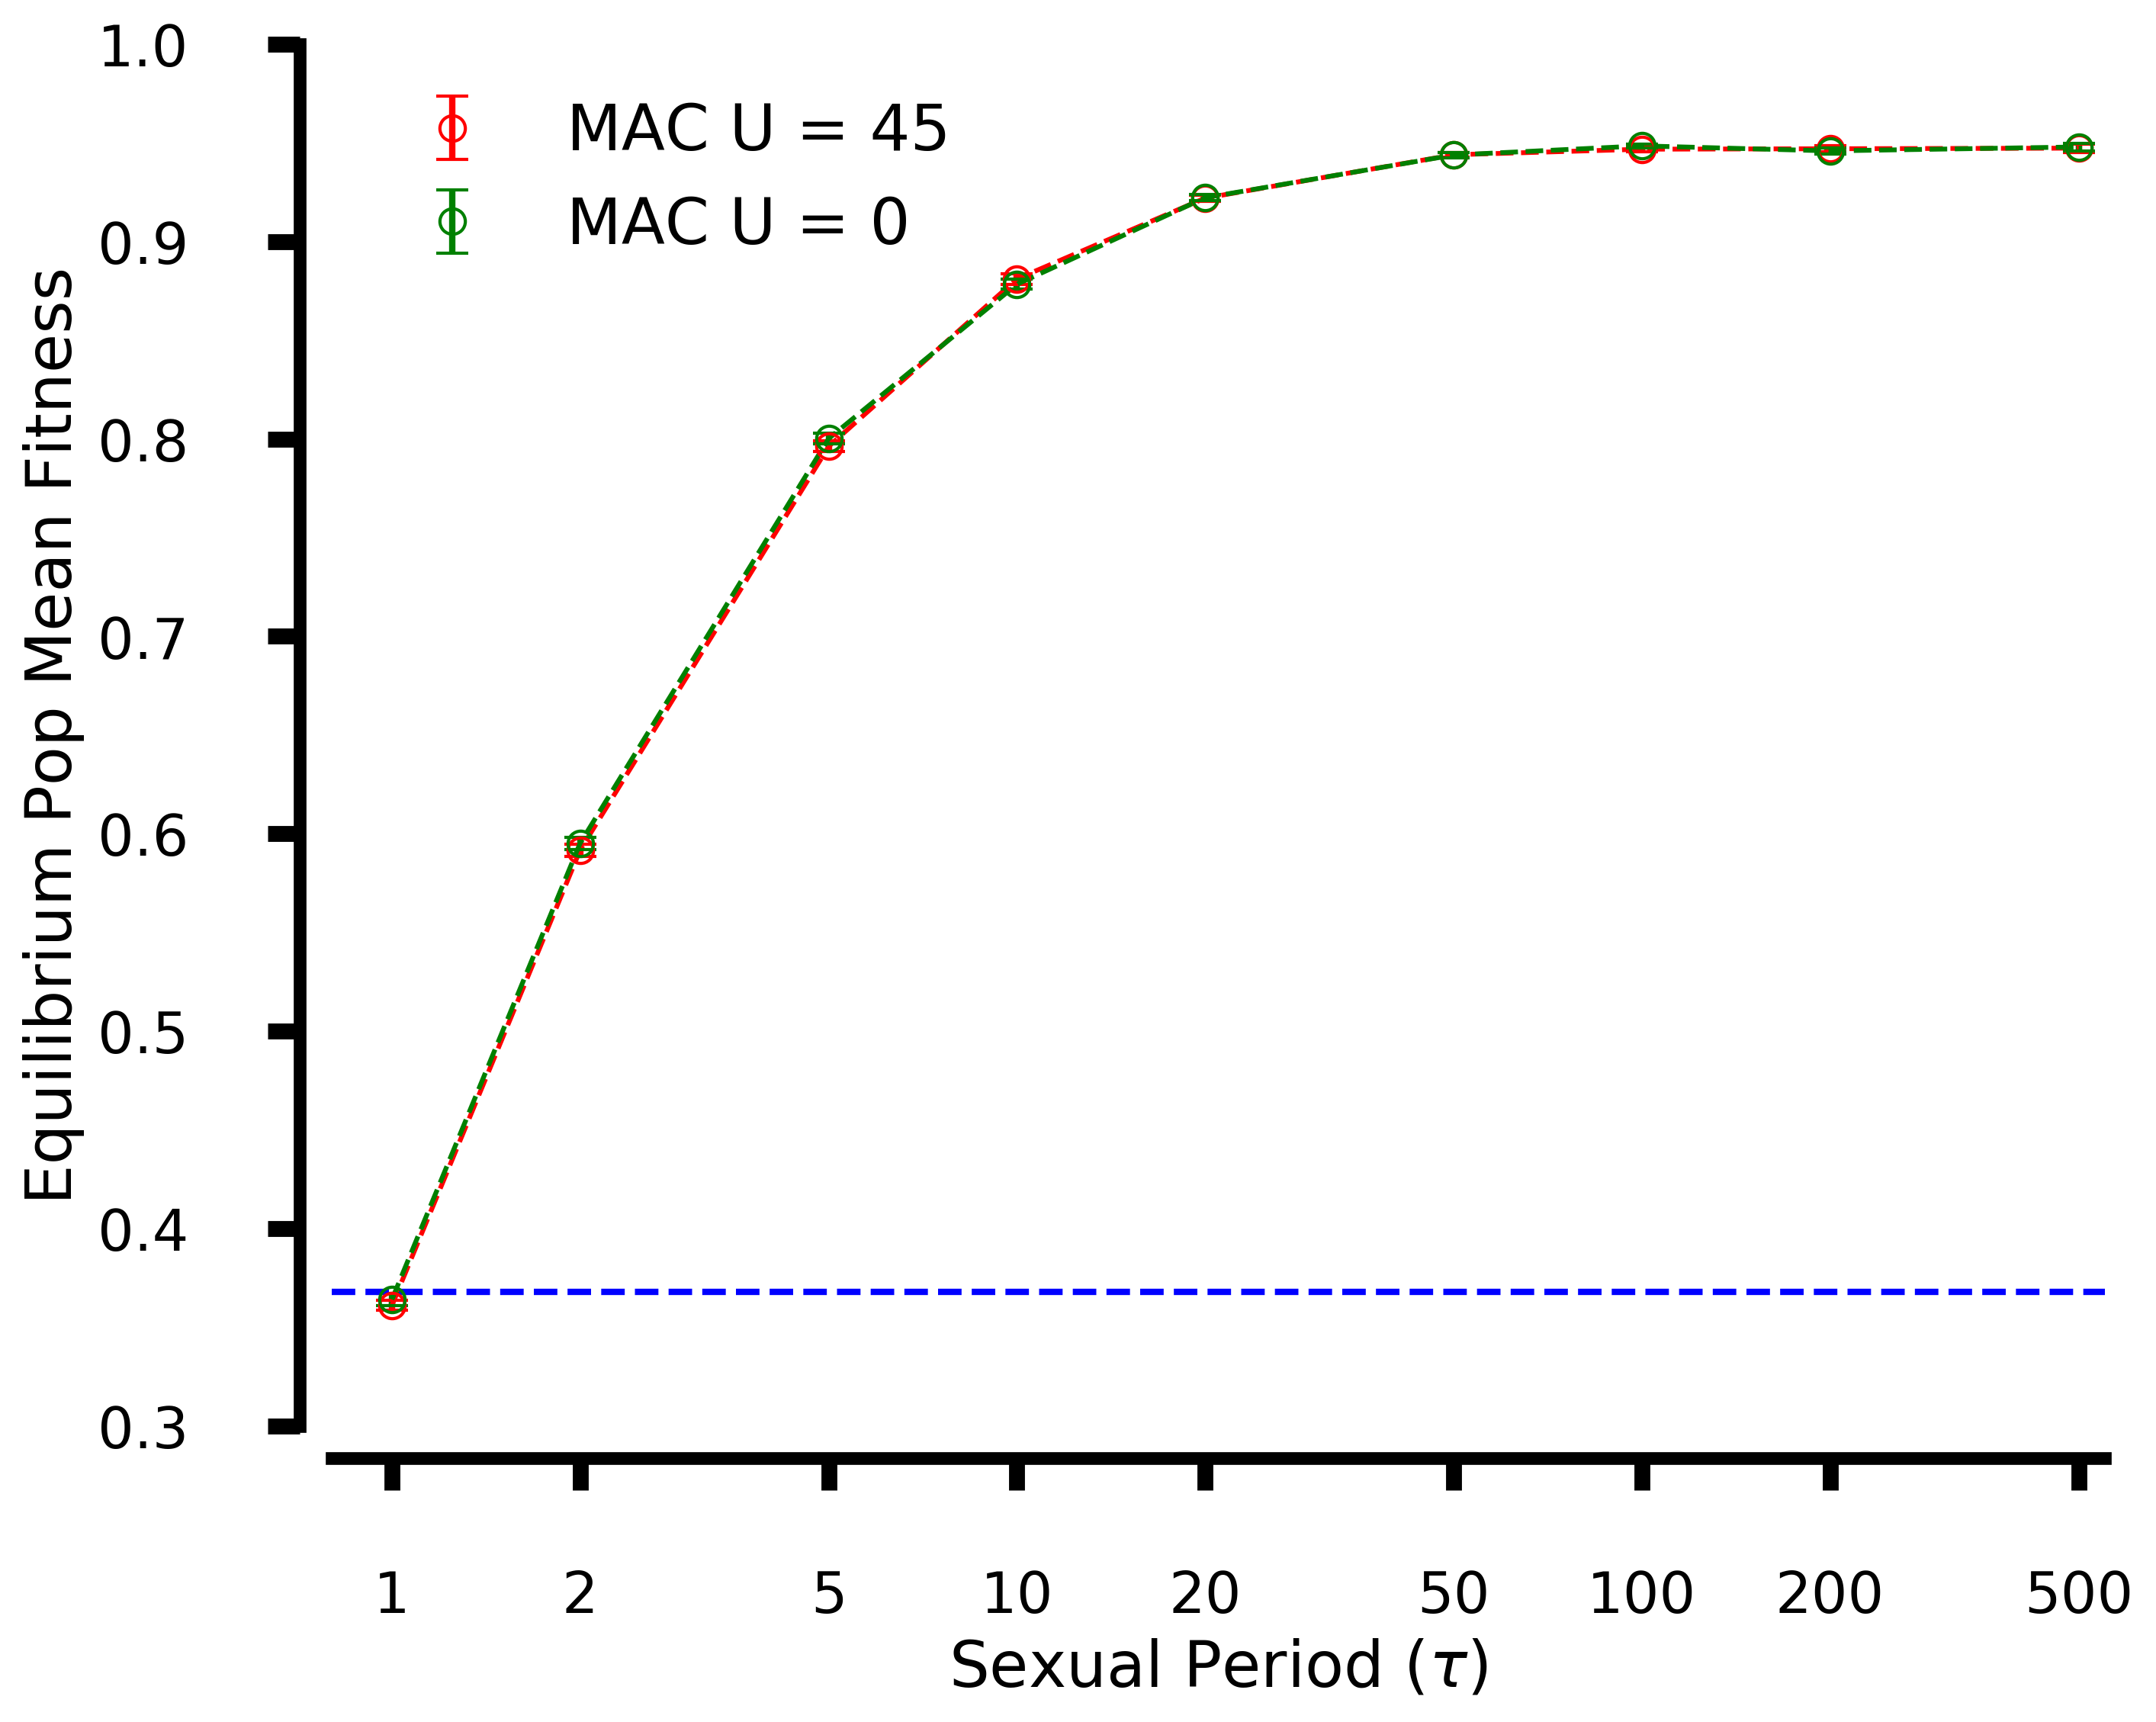

In [22]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10, 8), dpi = 300)
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_ylim(0.3, 1)
ax.set_xlim(0.8,550)

x = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xscale('log',basex=2)


# N =100
y1 = np.array(rmu_mean)
yerr1 = 1.98*np.array(rmu_std)/((100)**0.5)
ax.errorbar(x, y1, yerr = yerr1, label ='MAC U = 45', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y1, color = 'red', ls = '--')


y2 = np.array(s1_mean)
yerr2 = 1.98*np.array(s1_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='MAC U = 0', fmt='o', color = 'g', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'g', ls = '--')

ax.axhline(y=rm_expect, xmin=0, xmax=10, color ='b', lw =2, ls ='dashed')



plt.legend(loc='upper left', frameon=False, prop={'size':20})

ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500]) # choose which x locations to have ticks
ax.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500]) # set the labels to display at those ticks


ax.set_xlabel(r'Sexual Period $(\tau)$', fontsize =20)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =20)